# Forman Profile: learned sheaf curvature vs topological reference

## 1. Imports

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import scipy.sparse as sp
from scipy.stats import spearmanr, pearsonr, wasserstein_distance

## 2. Utility functions

In [2]:
def compute_F_diags_from_coo(lap, n, d):
    """
    Forman-Bochner diagonal blocks F_{u,u} from a COO sheaf Laplacian.

    L = B + F, where B_{u,u} = sum_{v~u} |L_{u,v}|  (matrix absolute value)
    and F_{u,u} = L_{u,u} - B_{u,u}.

    Parameters: lap — [row_idx, col_idx, values] COO tensors of the (n*d)x(n*d) Laplacian
    Returns:    F_diags — np.ndarray (n, d, d)
    """
    row_idx = lap[0].long().numpy().astype(np.int64)
    col_idx = lap[1].long().numpy().astype(np.int64)
    values  = lap[2].numpy()

    block_row = row_idx // d
    block_col = col_idx // d
    local_r   = row_idx % d
    local_c   = col_idx % d

    is_diag = (block_row == block_col)

    # Step 1: collect diagonal blocks L_{u,u}
    diag_blocks = np.zeros((n, d, d))
    dm = is_diag
    np.add.at(diag_blocks, (block_row[dm], local_r[dm], local_c[dm]), values[dm])

    # Step 2: group off-diagonal COO entries by (u,v) block pair
    off_mask = ~is_diag
    off_br   = block_row[off_mask]
    off_bc   = block_col[off_mask]
    off_lr   = local_r[off_mask]
    off_lc   = local_c[off_mask]
    off_vals = values[off_mask]

    # injective map (u,v) -> u*n+v
    block_ids = off_br * n + off_bc
    unique_ids, inverse = np.unique(block_ids, return_inverse=True)
    num_blocks = len(unique_ids)

    all_blocks = np.zeros((num_blocks, d, d))
    np.add.at(all_blocks, (inverse, off_lr, off_lc), off_vals)

    # Step 3: batch SVD to compute matrix_abs for all off-diagonal blocks
    # matrix_abs(A) = U diag(S) U^T
    nonzero_mask = np.any(all_blocks != 0, axis=(1, 2))
    abs_blocks = np.zeros_like(all_blocks)
    if np.any(nonzero_mask):
        nz = all_blocks[nonzero_mask]
        U, S, _ = np.linalg.svd(nz)
        abs_blocks[nonzero_mask] = np.einsum('bij,bj,bkj->bik', U, S, U)

    # Step 4: B_{u,u} = sum_{v~u} |L_{u,v}|
    B_diag = np.zeros((n, d, d))
    unique_block_rows = (unique_ids // n).astype(np.int64)
    np.add.at(B_diag, unique_block_rows, abs_blocks)

    # Step 5: F_{u,u} = L_{u,u} - B_{u,u}
    return diag_blocks - B_diag

## 3. Config

In [3]:
dataset         = "citeseer"  # "cora", "citeseer", "pubmed", "cornell", "wisconsin", "synthetic", "amazon-ratings", "questions", "tolokers"
model           = "GeneralSheaf"
Norm            = "true"
stalk_dim       = 5
layers          = 4
hidden_channels = 16
epochs          = 500
seed            = 43
#num_nodes = 22662 # Roman Empire
#num_nodes = 10000 # minsesweeper
#num_nodes = 2708 # Cora
num_nodes = 3327 # Citeseer 
#num_nodes = 19717 # Pubmed
#num_nodes = 183 # Cornell
#num_nodes = 500 # synthetic
#num_nodes      = 251  # Wisconsin
#num_nodes       = 24492 # Amazon Ratings
#num_nodes = 48921 # Questions
#num_nodes = 11758 # Tolokers
num_folds       = 10

# set mode="JointSheafParamsAlt" to activate the learn_first_maps filename tag
mode             = "General"
learn_first_maps = True
lfm_tag = f"_learn_first_maps-{str(learn_first_maps).lower()}" if mode == "JointSheafParamsAlt" else ""

n, d = num_nodes, stalk_dim

def lap_path(layer, fold):
    return (f"../results/laplacians/{dataset}/normalised-{Norm}/stalk_dim-{stalk_dim}/"
            f"{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs/"
            f"{model}_{dataset}_layer{layer}_fold{fold}{lfm_tag}_seed{seed}.pt")

## 4. Topological reference

The graph topology is fixed (same dataset, same splits) — build it once from any fold.

In [4]:
lap0    = torch.load(lap_path(layer=0, fold=0), weights_only=True)
row_idx = lap0[0].long().numpy()
col_idx = lap0[1].long().numpy()

edges = set()
for r, c in zip(row_idx, col_idx):
    u, v = int(r) // d, int(c) // d
    if u != v:
        edges.add((min(u, v), max(u, v)))

nodelist = list(range(n))
G = nx.Graph()
G.add_nodes_from(nodelist)
G.add_edges_from(sorted(edges))
print(f"{G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# normalized augmented Laplacian: D_aug^{-1/2} L D_aug^{-1/2},  D_aug = D + I
L_top_un   = nx.laplacian_matrix(G, nodelist=nodelist).astype(float)
degrees    = np.array(L_top_un.diagonal())
D_inv_sqrt = sp.diags(1.0 / np.sqrt(degrees + 1))
L_top_sp   = D_inv_sqrt @ L_top_un @ D_inv_sqrt

diag_vals    = np.array(L_top_sp.diagonal())
abs_row_sums = np.array(np.abs(L_top_sp).sum(axis=1)).ravel()
f0_top       = 2 * diag_vals - abs_row_sums

3327 nodes, 4552 edges


## 5. Forman curvature across all folds

`all_curv_eigs[fold, layer, node, k]` is the k-th eigenvalue of the Forman block F_{u,u}.

In [5]:
all_curv_eigs = np.zeros((num_folds, layers, n, d))

for fold in range(num_folds):
    for layer in range(layers):
        lap     = torch.load(lap_path(layer, fold), weights_only=True)
        F_diags = compute_F_diags_from_coo(lap, n, d)             # (n, d, d)
        all_curv_eigs[fold, layer] = np.linalg.eigvalsh(F_diags)  # (n, d)
    print(f"fold {fold} done")

mean_curv = all_curv_eigs.mean(axis=0)   # (layers, n, d)
std_curv  = all_curv_eigs.std(axis=0)    # (layers, n, d)

fold 0 done
fold 1 done
fold 2 done
fold 3 done
fold 4 done
fold 5 done
fold 6 done
fold 7 done
fold 8 done
fold 9 done


## 6. Mean Forman Profile

Each subplot shows the mean curvature eigenvalue (averaged over folds) vs the topological scalar curvature f0,
with a ±1 std band. Nodes are sorted by f0_top on the x-axis.
The Spearman ρ is computed on the mean profile.

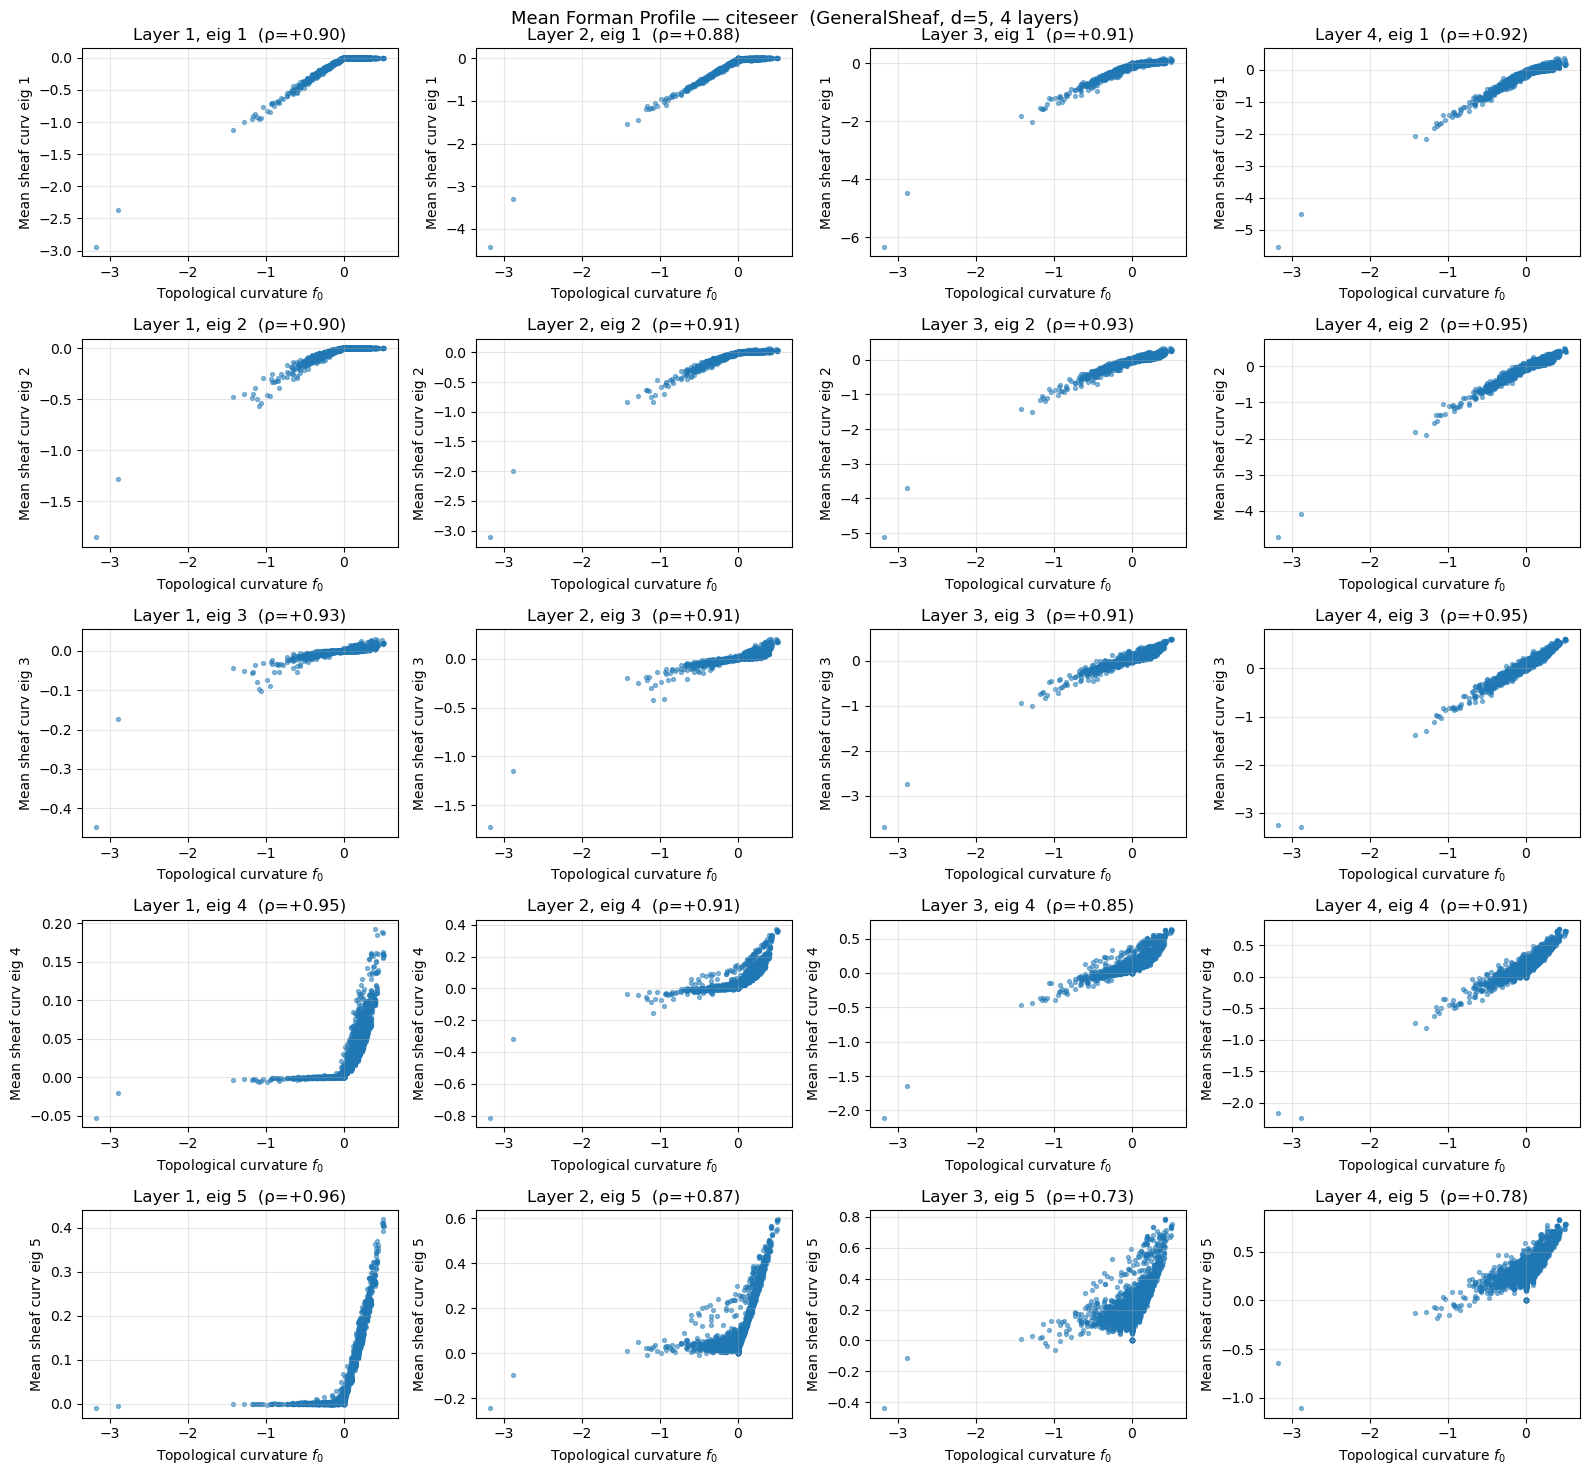

In [6]:
fig, axes = plt.subplots(d, layers, figsize=(4 * layers, 3 * d))
if layers == 1:
    axes = axes.reshape(-1, 1)

for k in range(d):
    for layer in range(layers):
        ax  = axes[k, layer]
        mu  = mean_curv[layer, :, k]
        rho = spearmanr(mu, f0_top).statistic

        ax.scatter(f0_top, mu, s=8, alpha=0.5)
        ax.set_title(f"Layer {layer+1}, eig {k+1}  (ρ={rho:+.2f})")
        ax.set_xlabel("Topological curvature $f_0$")
        ax.set_ylabel(f"Mean sheaf curv eig {k+1}")
        ax.grid(alpha=0.3)

fig.suptitle(f"Mean Forman Profile — {dataset}  ({model}, d={d}, {layers} layers)", fontsize=13)
fig.tight_layout()
#plt.savefig(f"../figures/{dataset}_{model}_d{d}_forman_profile.pdf", bbox_inches="tight")
plt.show()


## 7. Numerical metrics

For each fold we compute three alignment scores between each curvature eigenvalue channel and f0_top,
then report mean ± std across the 10 folds.

- **Spearman ρ**: rank correlation — scale-free, directly measures node-level alignment.
- **Pearson r**: linear correlation — catches how well the linear trend holds.
- **Wasserstein**: distance between the two normalized distributions — measures shape similarity independent of node ordering.
- **L2 distance**

In [7]:
f0_norm = (f0_top - f0_top.mean()) / f0_top.std()

spearman_vals    = np.zeros((num_folds, layers, d))
spearman_pvals   = np.zeros((num_folds, layers, d))
pearson_vals     = np.zeros((num_folds, layers, d))
pearson_pvals    = np.zeros((num_folds, layers, d))
wasserstein_vals = np.zeros((num_folds, layers, d))
l2_norm_vals     = np.zeros((num_folds, layers, d))
l2_raw_vals      = np.zeros((num_folds, layers, d))
scale_ratio_vals = np.zeros((num_folds, layers, d))

for fold in range(num_folds):
    for layer in range(layers):
        for k in range(d):
            c      = all_curv_eigs[fold, layer, :, k]
            c_norm = (c - c.mean()) / (c.std() + 1e-9)

            spr = spearmanr(c, f0_top)
            pe = pearsonr(c, f0_top)

            spearman_vals[fold, layer, k]    = spr.statistic
            spearman_pvals[fold, layer, k]   = spr.pvalue
            pearson_vals[fold, layer, k]     = pe.statistic
            pearson_pvals[fold, layer, k]    = pe.pvalue
            wasserstein_vals[fold, layer, k] = wasserstein_distance(c_norm, f0_norm)
            l2_norm_vals[fold, layer, k]     = np.linalg.norm(c_norm - f0_norm)
            l2_raw_vals[fold, layer, k]      = np.linalg.norm(c - f0_top)
            scale_ratio_vals[fold, layer, k] = c.std() / (f0_top.std() + 1e-9)

def fold_stats(arr):
    return arr.mean(axis=0), arr.std(axis=0)

spearman_mean,    spearman_std    = fold_stats(spearman_vals)
pearson_mean,     pearson_std     = fold_stats(pearson_vals)
wasserstein_mean, wasserstein_std = fold_stats(wasserstein_vals)
l2_norm_mean,     l2_norm_std     = fold_stats(l2_norm_vals)
l2_raw_mean,      l2_raw_std      = fold_stats(l2_raw_vals)
scale_ratio_mean, scale_ratio_std = fold_stats(scale_ratio_vals)

# plot style — defined once, shared by both plot cells
PALETTE = [
    "#E6A817",   # gold
    "#4169E1",   # royal blue
    "#E8735A",   # salmon
    "#5BAD6F",   # sage green
    "#9B72B0",   # soft purple
    "#5BB8C9",   # steel blue
    "#C97D4E",   # terracotta
    "#C75B8A",   # rose
]
colors      = PALETTE[:d]
layer_ticks = np.arange(1, layers + 1)

### Table

In [8]:
hdr1 = f"{'Layer':>6}  {'Eig':>4}  {'Spearman':>18}  {'Pearson':>18}  {'Wasserstein':>18}"
print(hdr1)
print("-" * len(hdr1))
for layer in range(layers):
    for k in range(d):
        print(f"{layer+1:>6}  {k+1:>4}  "
              f"{spearman_mean[layer,k]:+.3f} \u00b1 {spearman_std[layer,k]:.3f}  "
              f"{pearson_mean[layer,k]:+.3f} \u00b1 {pearson_std[layer,k]:.3f}  "
              f"{wasserstein_mean[layer,k]:.3f} \u00b1 {wasserstein_std[layer,k]:.3f}")

print()


 Layer   Eig            Spearman             Pearson         Wasserstein
------------------------------------------------------------------------
     1     1  +0.816 ± 0.030  +0.847 ± 0.022  0.418 ± 0.017
     1     2  +0.791 ± 0.041  +0.721 ± 0.103  0.501 ± 0.048
     1     3  +0.795 ± 0.074  +0.595 ± 0.097  0.497 ± 0.069
     1     4  +0.898 ± 0.077  +0.586 ± 0.094  0.519 ± 0.029
     1     5  +0.950 ± 0.015  +0.699 ± 0.025  0.473 ± 0.008
     2     1  +0.791 ± 0.046  +0.867 ± 0.020  0.367 ± 0.010
     2     2  +0.807 ± 0.048  +0.779 ± 0.079  0.427 ± 0.033
     2     3  +0.798 ± 0.071  +0.707 ± 0.087  0.381 ± 0.086
     2     4  +0.836 ± 0.121  +0.675 ± 0.100  0.440 ± 0.028
     2     5  +0.863 ± 0.071  +0.671 ± 0.078  0.432 ± 0.024
     3     1  +0.788 ± 0.030  +0.852 ± 0.015  0.308 ± 0.022
     3     2  +0.801 ± 0.039  +0.838 ± 0.029  0.274 ± 0.035
     3     3  +0.778 ± 0.048  +0.818 ± 0.043  0.212 ± 0.059
     3     4  +0.740 ± 0.056  +0.729 ± 0.052  0.297 ± 0.041
     3     5  

In [9]:
hdr2 = f"{'Layer':>6}  {'Eig':>4}  {'L2 norm':>18}  {'L2 raw':>18}  {'Scale ratio':>18}"
print(hdr2)
print("-" * len(hdr2))
for layer in range(layers):
    for k in range(d):
        print(f"{layer+1:>6}  {k+1:>4}  "
              f"{l2_norm_mean[layer,k]:.3f} \u00b1 {l2_norm_std[layer,k]:.3f}  "
              f"{l2_raw_mean[layer,k]:.3f} \u00b1 {l2_raw_std[layer,k]:.3f}  "
              f"{scale_ratio_mean[layer,k]:.3f} \u00b1 {scale_ratio_std[layer,k]:.3f}")

 Layer   Eig             L2 norm              L2 raw         Scale ratio
------------------------------------------------------------------------
     1     1  31.842 ± 2.211  8.417 ± 0.373  0.582 ± 0.105
     1     2  42.424 ± 7.455  10.069 ± 0.918  0.287 ± 0.129
     1     3  51.483 ± 6.716  11.631 ± 0.534  0.053 ± 0.061
     1     4  52.147 ± 5.801  10.942 ± 0.699  0.141 ± 0.086
     1     5  44.716 ± 1.800  9.476 ± 0.435  0.372 ± 0.101
     2     1  29.706 ± 2.126  8.491 ± 0.348  0.839 ± 0.048
     2     2  37.751 ± 6.630  9.062 ± 0.816  0.481 ± 0.142
     2     3  43.591 ± 6.806  10.056 ± 0.995  0.259 ± 0.130
     2     4  45.998 ± 6.961  9.821 ± 0.812  0.315 ± 0.128
     2     5  46.493 ± 5.151  10.016 ± 0.782  0.598 ± 0.033
     3     1  31.314 ± 1.528  10.149 ± 0.382  1.088 ± 0.041
     3     2  32.705 ± 2.926  7.507 ± 0.357  0.884 ± 0.088
     3     3  34.572 ± 4.364  6.898 ± 0.785  0.754 ± 0.113
     3     4  42.266 ± 4.106  9.313 ± 0.456  0.705 ± 0.088
     3     5  55.970 ±

### Metrics (Spearman, Pearson, Wasserstein, L2 of row values, L2 of normalized values)

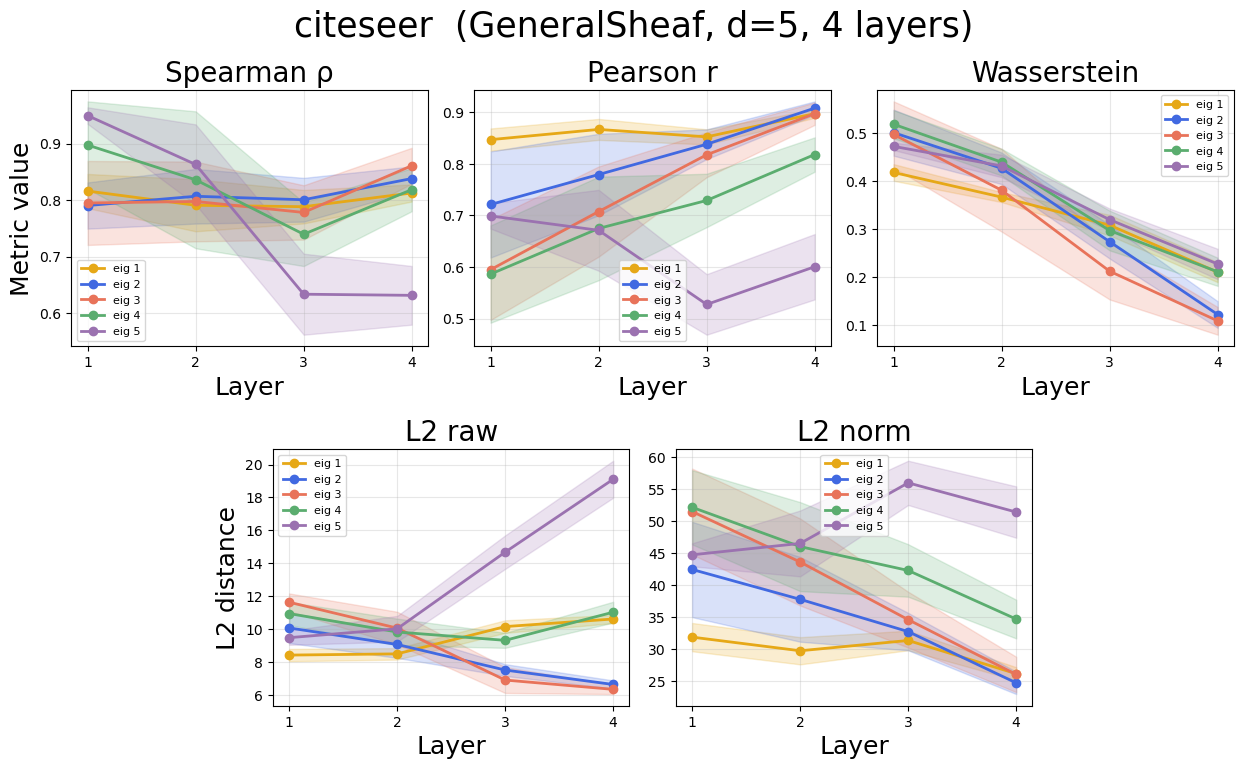

In [10]:
fig = plt.figure(figsize=(15, 8))
gs  = fig.add_gridspec(2, 6, hspace=0.4, wspace=0.3)

ax_sp  = fig.add_subplot(gs[0, 0:2])
ax_pe  = fig.add_subplot(gs[0, 2:4])
ax_wa  = fig.add_subplot(gs[0, 4:6])
ax_l2r = fig.add_subplot(gs[1, 1:3])
ax_l2n = fig.add_subplot(gs[1, 3:5])

all_metrics = [
    (ax_sp,  "Spearman \u03c1",  spearman_mean,    spearman_std),
    (ax_pe,  "Pearson r",     pearson_mean,     pearson_std),
    (ax_wa,  "Wasserstein",   wasserstein_mean, wasserstein_std),
    (ax_l2r, "L2 raw",        l2_raw_mean,      l2_raw_std),
    (ax_l2n, "L2 norm",       l2_norm_mean,     l2_norm_std),
]

for ax, title, mu_mat, sig_mat in all_metrics:
    for k in range(d):
        mu  = mu_mat[:, k]
        sig = sig_mat[:, k]
        ax.plot(layer_ticks, mu, marker='o', color=colors[k], label=f"eig {k+1}", lw=2)
        ax.fill_between(layer_ticks, mu - sig, mu + sig, alpha=0.2, color=colors[k])
    ax.set_title(title, fontsize=20)
    ax.set_xlabel("Layer", fontsize=18)
    ax.set_xticks(layer_ticks)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

ax_sp.set_ylabel("Metric value", fontsize=18)
ax_l2r.set_ylabel("L2 distance", fontsize=18)

fig.suptitle(f"{dataset}  ({model}, d={d}, {layers} layers)", fontsize=25)
#plt.savefig(f"metric_images/{dataset}_{model}_d{d}_{layers}L_Norm_{Norm}_all_metrics.pdf", bbox_inches="tight")
plt.show()
